In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import spearmanr, zscore
from scipy.special import logit, expit
from statsmodels.stats.multitest import multipletests
from ALLCools.mcds import MCDS 

# Define paths
mcds_path = '/ceph/MethDev/pbio/hazel/gene_mcds/gene'
rna_path = '/ceph/MethDev/pbio/hazel/count_Arab13_with_TEs.csv'
meta_path = '/ceph/MethDev/pbio/hazel/merged_cluster_assignments.csv'

# Load datasets
mcds = MCDS.open(mcds_paths=mcds_path, var_dim='gene')
rna = pd.read_csv(rna_path).T
meta = pd.read_csv(meta_path).set_index('cell_id')

print(f"Loaded RNA shape: {rna.shape}")
print(f"Loaded Meta shape: {meta.shape}")

Loaded RNA shape: (6071, 64507)
Loaded Meta shape: (5908, 1)


In [2]:
# 1. Define the path to your specific gene list
gene_list_path = '/ceph/MethDev/pbio/andy/JW/section_4/section_4b_chunk_feature_analysis/ctsGbM.c1171.genes.txt'

# 2. Read the genes from the text file
# (This assumes the file has one gene ID per line)
with open(gene_list_path, 'r') as f:
    target_genes = [line.strip() for line in f if line.strip()]

print(f"Loaded {len(target_genes)} genes from the text file.")

Loaded 1171 genes from the text file.


In [3]:
# ==========================================
# CELL 3: BUILD UNCOLLAPSED RNA MATRIX
# ==========================================
# 1. Define the mapping and desired order
cluster_mapping = {
    3: '3 Early M', 0: '0 Mid M', 7: '7 Expanding M', 1: '1 Late M', 10: '10 Senescent M',
    5: '5 Early E', 4: '4 Abaxial E', 6: '6 Adaxial E', 13: '13 Expanding E', 8: '8 Senescent E',
    14: '14 Guard cell', 2: '2 Vasculature', 11: '11 PPP', 9: '9 Phloem', 
    16: '16 Myrosinase', 12: '12 S phase', 15: '15 G2M phase'
}
# Support string keys in case index types vary
cluster_mapping.update({str(k): v for k, v in cluster_mapping.items()})

cluster_order = [
    '3 Early M', '0 Mid M', '7 Expanding M', '1 Late M', '10 Senescent M',
    '5 Early E', '13 Expanding E', '4 Abaxial E', '6 Adaxial E', '8 Senescent E',
    '14 Guard cell', '2 Vasculature', '11 PPP', '9 Phloem', 
    '16 Myrosinase', '12 S phase', '15 G2M phase'
]

# 2. Align cells
common_cells = rna.index.intersection(meta.index)
rna_aligned = rna.loc[common_cells]

# 3. Normalize to CPM and Log1p transform
cell_totals = rna_aligned.sum(axis=1)
rna_cpm = rna_aligned.div(cell_totals, axis=0) * 1e6
rna_log1p = np.log1p(rna_cpm)

# 4. Map the fine-grained clusters instead of 'merged_cluster'
# Assuming the single column in your meta file holds the cluster ID (0-16)
meta_col_name = meta.columns[0]
fine_clusters = meta.loc[common_cells, meta_col_name].map(cluster_mapping)
rna_log1p['fine_cluster'] = fine_clusters

# 5. Aggregate by the new fine-grained clusters
uncollapsed_rna_matrix = rna_log1p.groupby('fine_cluster').mean().T
uncollapsed_rna_matrix = uncollapsed_rna_matrix[cluster_order] # Force correct order

print(f"Uncollapsed RNA matrix shape: {uncollapsed_rna_matrix.shape}")


# ==========================================
# CELL 4: BUILD UNCOLLAPSED METHYLATION MATRIX
# ==========================================
# 1. Get raw counts (c = methylated, m = total coverage)
mCGN_mc = mcds.sel(mc_type='CGN', count_type='mc').gene_da.to_pandas()
mCGN_cov = mcds.sel(mc_type='CGN', count_type='cov').gene_da.to_pandas()

# Map the fine-grained clusters
mCGN_mc['fine_cluster'] = meta[meta_col_name].map(cluster_mapping)
mCGN_cov['fine_cluster'] = meta[meta_col_name].map(cluster_mapping)

# Aggregate counts by fine cluster
cluster_c = mCGN_mc.groupby('fine_cluster').sum().T.reindex(columns=cluster_order)
uncollapsed_cluster_m = mCGN_cov.groupby('fine_cluster').sum().T.reindex(columns=cluster_order)

# 2. Fit Global Offsets (deltas)
global_c = cluster_c.sum(axis=0)
global_m = uncollapsed_cluster_m.sum(axis=0)
global_p = global_c / global_m

d = logit(np.clip(global_p, 1e-6, 1-1e-6))
deltas = d - np.average(d, weights=global_m)

# 3. Calculate Expected Methylation (p0)
gene_c = cluster_c.sum(axis=1)
gene_m = uncollapsed_cluster_m.sum(axis=1)

valid_genes_mask = gene_m >= 50 
cluster_c = cluster_c[valid_genes_mask]
cluster_m_filt = uncollapsed_cluster_m[valid_genes_mask]
gene_c = gene_c[valid_genes_mask]
gene_m = gene_m[valid_genes_mask]

pbar = np.clip(gene_c / gene_m, 1e-6, 1-1e-6)
logit_pbar = logit(pbar).values[:, None]
expected_logit = logit_pbar + deltas.values[None, :]
p0_df = pd.DataFrame(expit(expected_logit), index=cluster_c.index, columns=cluster_c.columns)

# 4. Extract Adjusted Matrix
obs_p = cluster_c / cluster_m_filt.replace(0, np.nan)
obs_p = obs_p.fillna(0) 

uncollapsed_adj_meth_matrix = obs_p - p0_df

print(f"Uncollapsed Meth Residuals matrix shape: {uncollapsed_adj_meth_matrix.shape}")

Uncollapsed RNA matrix shape: (64507, 17)
Uncollapsed Meth Residuals matrix shape: (32357, 17)


In [5]:
# ==========================================
# REFACTORED COMBINATORIAL HEATMAP SCRIPT
# ==========================================
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as hc
import scipy.spatial as sp
import statsmodels.api as sm
from scipy.stats import zscore
from statsmodels.stats.multitest import multipletests
from matplotlib.colors import LinearSegmentedColormap

teal_rust_cmap = LinearSegmentedColormap.from_list("Teal_Rust", ["#FF8C00", "white", "#004d4d"])
rna_cmap = LinearSegmentedColormap.from_list("Grey_Green", ["white", "forestgreen"])

# Re-assign variables for clean reading
rna_df = uncollapsed_rna_matrix
meth_df = uncollapsed_adj_meth_matrix
weights_df = uncollapsed_cluster_m

# 1. Define the 3 Cluster Dimensions
meso_epi_cols = [c for c in cluster_order if c.endswith('M') or c.endswith('E')]
non_meso_epi_cols = [c for c in cluster_order if c not in meso_epi_cols]

cluster_dims = {
    'all_clusters': cluster_order,
    'meso_epi': meso_epi_cols,
    'non_meso_epi': non_meso_epi_cols
}

# 2. Define the 2 Gene Dimensions
all_metadata_genes = rna_df.index.intersection(meth_df.index)
gene_dims = {
    '30k_genes': all_metadata_genes,
    'hazel_genes': all_metadata_genes.intersection(target_genes)
}

# ==========================================
# HELPER FUNCTIONS
# ==========================================
def calculate_wls_stats(genes, subset_cols):
    """Calculates WLS specifically on the selected column subset with R2 and Beta tracking."""
    valid_genes, p_vals, coefs, r2_vals = [], [], [], []
    for gene in genes:
        r_vals = rna_df.loc[gene, subset_cols].values
        m_vals = meth_df.loc[gene, subset_cols].values
        w_vals = weights_df.loc[gene, subset_cols].values
        
        if np.std(r_vals) == 0 or np.std(m_vals) == 0:
            continue
            
        try:
            mod = sm.WLS(zscore(r_vals), sm.add_constant(zscore(m_vals)), weights=w_vals).fit()
            valid_genes.append(gene)
            p_vals.append(mod.pvalues[1])  
            coefs.append(mod.params[1])    # The slope (Beta)
            r2_vals.append(mod.rsquared)   # The R-squared value
        except:
            continue

    stats_df = pd.DataFrame({
        'pval': p_vals, 
        'coef': coefs, 
        'r2': r2_vals
    }, index=valid_genes)
    
    if len(stats_df) > 0:
        stats_df['fdr'] = multipletests(stats_df['pval'], method='fdr_bh')[1]
    
    return stats_df

# Example of how to filter this later:
# strict_wls_genes = stats_df[(stats_df['fdr'] < 0.05) & (stats_df['coef'] < 0) & (stats_df['r2'] > 0.3)].index

def get_clustered_data(genes, cols):
    """Z-scores and hierarchically clusters genes for the target columns."""
    z_meth = meth_df.loc[genes, cols].apply(zscore, axis=1).clip(-2.5, 2.5).fillna(0)
    z_rna = rna_df.loc[genes, cols].apply(zscore, axis=1).clip(-2.5, 2.5).fillna(0)
    
    if len(genes) > 1:
        linkage = hc.linkage(sp.distance.pdist(z_meth.values), method='ward')
        order = hc.leaves_list(linkage)
        return z_meth.iloc[order], z_rna.iloc[order]
    return z_meth, z_rna


def get_clustered_data_anchored(genes, plot_cols, anchor_cols):
    """
    Z-scores and clusters genes based ONLY on the anchor_cols,
    but outputs the data for all plot_cols to show expansion.
    """
    # 1. Calculate Mean and Std ONLY on the anchor (subset) columns
    # Using ddof=0 to perfectly match scipy.stats.zscore behavior
    meth_mean = meth_df.loc[genes, anchor_cols].mean(axis=1)
    meth_std = meth_df.loc[genes, anchor_cols].std(axis=1, ddof=0).replace(0, 1) 
    
    rna_mean = rna_df.loc[genes, anchor_cols].mean(axis=1)
    rna_std = rna_df.loc[genes, anchor_cols].std(axis=1, ddof=0).replace(0, 1)
    
    # 2. Apply this subset-derived Mean & Std to ALL requested plot columns
    z_meth_plot = meth_df.loc[genes, plot_cols].sub(meth_mean, axis=0).div(meth_std, axis=0).clip(-2.5, 2.5).fillna(0)
    z_rna_plot = rna_df.loc[genes, plot_cols].sub(rna_mean, axis=0).div(rna_std, axis=0).clip(-2.5, 2.5).fillna(0)
    
    # 3. Perform Hierarchical Clustering ONLY on the anchor columns
    z_meth_anchor = z_meth_plot[anchor_cols] 
    
    if len(genes) > 1:
        linkage = hc.linkage(sp.distance.pdist(z_meth_anchor.values), method='ward')
        order = hc.leaves_list(linkage)
        
        # Apply the subset-driven row order to the full dataset
        return z_meth_plot.iloc[order], z_rna_plot.iloc[order]
        
    return z_meth_plot, z_rna_plot

def plot_standalone_heatmap(genes, plot_cols, title, save_path, anchor_cols=None):
    """Generates a standalone 1x2 heatmap, with optional anchoring for Z-scores/clustering."""
    if len(genes) == 0:
        print(f"⚠️ Skipping plot '{title}' - no genes survived filters.")
        return
        
    # Check if we should use the anchored calculation or the standard one
    if anchor_cols is not None:
        m_plot, r_plot = get_clustered_data_anchored(genes, plot_cols, anchor_cols)
    else:
        m_plot, r_plot = get_clustered_data(genes, plot_cols)
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 8))
    
    # Meth Heatmap - Lock vmin and vmax!
    sns.heatmap(m_plot, cmap="coolwarm", center=0, vmin=-2.5, vmax=2.5, 
                ax=axes[0], cbar_kws={'label': 'Meth Z'}, yticklabels=False)
    axes[0].set_title(f"{title}\nMethylation Residuals (n={len(genes)})", fontsize=14, pad=10)
    
    # RNA Heatmap - Lock vmin and vmax!
    sns.heatmap(r_plot, cmap=teal_rust_cmap, vmin=-2.5, vmax=2.5, 
                ax=axes[1], cbar_kws={'label': 'RNA Z'}, yticklabels=False)
    axes[1].set_title(f"{title}\nRNA Expression (n={len(genes)})", fontsize=14, pad=10)

    # Dynamic Formatting & Dividers
    for ax in axes:
        ax.set_xlabel("")
        ax.set_ylabel("")
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=11)
        
        if len(plot_cols) == 17:
            ax.axvline(5, color='black', lw=2, linestyle=':')  
            ax.axvline(10, color='black', lw=2, linestyle=':')
        elif len(plot_cols) == 10:
            ax.axvline(5, color='black', lw=2, linestyle=':')

    plt.tight_layout()
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
    plt.close() 
    print(f"✅ Saved: {save_path}")



In [6]:
# 3. Filter to ensure these genes actually exist in our loaded matrices
# This prevents KeyErrors if the text file contains genes that were filtered out of your matrices earlier!
valid_genes = [g for g in target_genes if g in rna_df.index and g in meth_df.index]
print(f"Found {len(valid_genes)} valid genes present in both RNA and Methylation matrices.")

Found 1145 valid genes present in both RNA and Methylation matrices.


In [7]:
# 4. Define where to save the resulting heatmap
save_dir = '/ceph/MethDev/pbio/kay/figures/heatmaps_custom/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, 'ctsGbM_c1171_genes_heatmap.png')

# 5. Generate the heatmap using your existing combinatorial function
if len(valid_genes) > 0:
    print(f"Clustering and plotting {len(valid_genes)} genes... (this might take a few seconds)")
    
    plot_standalone_heatmap(
        genes=valid_genes, 
        plot_cols=cluster_order,                # Plot across all 17 columns
        title=f"Custom Gene List: ctsGbM.c1171\n({len(valid_genes)} Genes, All Clusters)", 
        save_path=save_path
        # No anchor_cols needed here, as we are plotting standard Z-scores across the whole plant
    )
    
    # Show the plot inline in your Jupyter Notebook
    import matplotlib.pyplot as plt
    plt.show()
    
else:
    print("⚠️ No valid genes found to plot. Please check the gene IDs format in your text file.")

Clustering and plotting 1145 genes... (this might take a few seconds)
✅ Saved: ./figures/heatmaps_custom/ctsGbM_c1171_genes_heatmap.png


In [12]:
len(valid_genes)

1145

Calculating standard global WLS...

Total genes with Negative Slope AND R2 > 0.3: 177

--- TOP 10 GENES (No P-value filter applied yet) ---


,coef,r2,pval,fdr
AT4G01130,-0.939587,0.894405,1.012187e-08,0.000004
AT4G18970,-0.951620,0.893417,1.085922e-08,0.000004
AT2G33060,-0.828216,0.888696,1.506467e-08,0.000004
AT1G66100,-1.060066,0.853232,1.220570e-07,0.000026
AT3G26650,-0.945620,0.840921,2.247269e-07,0.000040
AT1G11350,-0.888270,0.837166,2.682223e-07,0.000041
AT1G62030,-0.894577,0.813089,7.640813e-07,0.000101
AT2G34430,-1.180831,0.809658,8.773747e-07,0.000101
AT2G07698,-0.942712,0.806817,9.819966e-07,0.000101
AT2G10940,-0.958572,0.805281,1.042917e-06,0.000101



--- IMPACT OF P-VALUE FILTERS ---
Genes remaining if you add raw p < 0.05: 177 (lost 0)
Genes remaining if you add FDR < 0.05:   132 (lost 45)


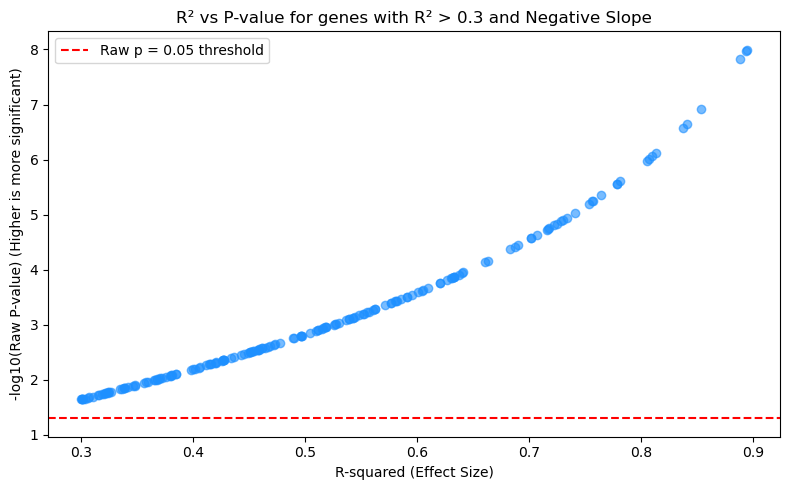

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. Run the updated WLS on your "standard condition" (e.g., all 17 clusters, 30k genes)
# Make sure you are using the updated calculate_wls_stats function that returns 'coef' and 'r2'
print("Calculating standard global WLS...")
standard_stats_df = calculate_wls_stats(valid_genes, cluster_order)

# 2. Apply ONLY the Beta and R-squared filters first
base_filtered_df = standard_stats_df[
    (standard_stats_df['coef'] < 0) & 
    (standard_stats_df['r2'] > 0.3)
].copy()

# Sort by R2 to see the strongest correlations at the top
base_filtered_df = base_filtered_df.sort_values('r2', ascending=False)

print(f"\nTotal genes with Negative Slope AND R2 > 0.3: {len(base_filtered_df)}")

# 3. Glimpse the top 10 genes without the p-value filter
print("\n--- TOP 10 GENES (No P-value filter applied yet) ---")
display(base_filtered_df[['coef', 'r2', 'pval', 'fdr']].head(10))

# 4. Check how many of these ALSO pass a raw p < 0.05 or FDR < 0.05
pass_raw_p = base_filtered_df[base_filtered_df['pval'] < 0.05]
pass_fdr = base_filtered_df[base_filtered_df['fdr'] < 0.05]

print(f"\n--- IMPACT OF P-VALUE FILTERS ---")
print(f"Genes remaining if you add raw p < 0.05: {len(pass_raw_p)} (lost {len(base_filtered_df) - len(pass_raw_p)})")
print(f"Genes remaining if you add FDR < 0.05:   {len(pass_fdr)} (lost {len(base_filtered_df) - len(pass_fdr)})")

# 5. Quick visual diagnostic: R-squared vs -log10(P-value)
plt.figure(figsize=(8, 5))
plt.scatter(base_filtered_df['r2'], -np.log10(base_filtered_df['pval']), alpha=0.6, color='dodgerblue')
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='Raw p = 0.05 threshold')

plt.title("R² vs P-value for genes with R² > 0.3 and Negative Slope")
plt.xlabel("R-squared (Effect Size)")
plt.ylabel("-log10(Raw P-value) (Higher is more significant)")
plt.legend()
plt.tight_layout()
plt.show()

In [16]:
import os

# 1. Extract the exact list of genes from your filtered dataframe
target_genes = base_filtered_df.index.tolist()

# 2. Define where to save the image
save_dir = '/ceph/MethDev/pbio/kay/figures/heatmaps_refined/'
os.makedirs(save_dir, exist_ok=True)
save_path = os.path.join(save_dir, '177_wls_negative_r2_filtered.png')

# 3. Generate the heatmap using your existing function
print(f"Clustering and plotting {len(target_genes)} genes... (this might take a few seconds)")

plot_standalone_heatmap(
    genes=target_genes, 
    plot_cols=cluster_order,                # Plot across all 17 columns
    title="Global WLS Repressors\n(Negative Slope, R² > 0.3)", 
    save_path=save_path
    # No anchor_cols needed here, because we are plotting all columns 
    # based on a WLS run on all columns!
)

# Optional: Also show the plot in the notebook inline
import matplotlib.pyplot as plt
plt.show()

print(f"✅ Heatmap successfully saved to: {save_path}")

Clustering and plotting 177 genes... (this might take a few seconds)
✅ Saved: ./figures/heatmaps_refined/177_wls_negative_r2_filtered.png
✅ Heatmap successfully saved to: ./figures/heatmaps_refined/177_wls_negative_r2_filtered.png
